In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
import os

Unzipping archive...
Found 60000 images belonging to 10 classes.
Found 10000 images belonging to 10 classes.
Building Advanced CNN Architecture...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 11, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 3, 3, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 392,330 (1.50 MB)

 Trainable params: 391,370 (1.49 MB)

 Non-trainable params: 960 (3.75 KB)

Starting Training for 15 epochs...
Epoch 1/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 156s 160ms/step - accuracy: 0.7634 - loss: 0.6494 - val_accuracy: 0.8335 - val_loss: 0.4776
Epoch 2/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 141s 151ms/step - accuracy: 0.8338 - loss: 0.4476 - val_accuracy: 0.8645 - val_loss: 0.3779
Epoch 3/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 139s 148ms/step - accuracy: 0.8511 - loss: 0.4034 - val_accuracy: 0.8681 - val_loss: 0.3570
Epoch 4/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 142s 152ms/step - accuracy: 0.8603 - loss: 0.3775 - val_accuracy: 0.8782 - val_loss: 0.3264
Epoch 5/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 147s 157ms/step - accuracy: 0.8684 - loss: 0.3558 - val_accuracy: 0.8492 - val_loss: 0.4008
Epoch 6/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 144s 154ms/step - accuracy: 0.8707 - loss: 0.3472 - val_accuracy: 0.8635 - val_loss: 0.3652
Epoch 7/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 141s 151ms/step - accuracy: 0.8765 - loss: 0.3331 - val_accuracy: 0.8765 - val_loss: 0.3592
Epoch 8/15
938/938 ━━━━━━━━━━━━━━━━━━━━ 1

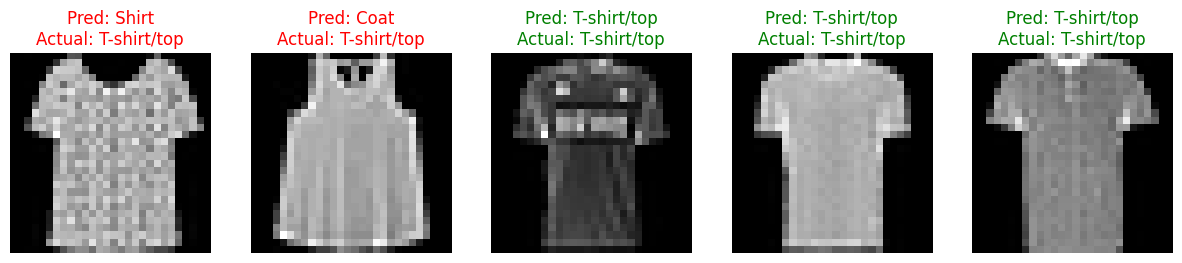

In [18]:


# --- STEP 1: UNZIP THE FILE ---
# If we uploaded a folder directly, we can skip this part.
if os.path.exists('/content/archive.zip'):
    print("Unzipping archive...")
    # The '-o' flag tells Linux to overwrite existing files automatically
    !unzip -o -q /content/archive.zip -d /content/archive_folder

    DATASET_PATH = "/content/archive_folder"
else:
    # If we uploaded a folder named 'archive' directly
    DATASET_PATH = "/content/archive"


class FashionMNISTCNN:
    def __init__(self, base_path, img_size=(28, 28), batch_size=64): # Increased batch size for BatchNorm stability
        self.base_path = base_path
        self.img_size = img_size
        self.batch_size = batch_size
        self.train_dir = os.path.join(base_path, 'train')
        self.test_dir = os.path.join(base_path, 'test')
        self.model = None

    def preprocess_data(self):
        """Creates Data Generators with Augmentation for Training."""
        # 1. DATA AUGMENTATION: Helps the model generalize better
        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=10,      # Slightly rotate images
            width_shift_range=0.1,  # Shift horizontally
            height_shift_range=0.1, # Shift vertically
            horizontal_flip=True,   # Flip images (shirts look same flipped)
            fill_mode='nearest'
        )

        # Validation data should ONLY be rescaled (not augmented)
        test_datagen = ImageDataGenerator(rescale=1./255)

        self.train_generator = train_datagen.flow_from_directory(
            self.train_dir,
            target_size=self.img_size,
            batch_size=self.batch_size,
            color_mode='grayscale',
            class_mode='sparse',
            shuffle=True
        )

        self.test_generator = test_datagen.flow_from_directory(
            self.test_dir,
            target_size=self.img_size,
            batch_size=self.batch_size,
            color_mode='grayscale',
            class_mode='sparse',
            shuffle=False
        )

    def build_cnn(self):
        """CNN with Batch Normalization and deeper layers."""
        print("Building Advanced CNN Architecture...")
        self.model = models.Sequential([
            # First Block
            layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
            layers.BatchNormalization(), # STABILIZES TRAINING
            layers.MaxPooling2D((2, 2)),

            # Second Block
            layers.Conv2D(64, (3, 3), activation='relu'),
            layers.BatchNormalization(), # STABILIZES TRAINING
            layers.MaxPooling2D((2, 2)),

            # Third Block (Added for more features)
            layers.Conv2D(128, (3, 3), activation='relu'),
            layers.BatchNormalization(),

            layers.Flatten(),
            layers.Dense(256, activation='relu'),
            layers.BatchNormalization(),
            layers.Dropout(0.4), # Increased dropout for regularization
            layers.Dense(10, activation='softmax')
        ])

        self.model.compile(
            optimizer='adam',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        self.model.summary()

    def train_model(self, epochs=15): # Added 5 more epochs for augmentation
        print(f"Starting Training for {epochs} epochs...")
        self.history = self.model.fit(
            self.train_generator,
            epochs=epochs,
            validation_data=self.test_generator
        )

    def visualize_predictions(self, num_images=5):
        class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
                       'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

        # Reset generator to get fresh images
        self.test_generator.reset()
        test_images, test_labels = next(self.test_generator)
        predictions = self.model.predict(test_images)

        plt.figure(figsize=(15, 6))
        for i in range(num_images):
            plt.subplot(1, num_images, i + 1)
            plt.imshow(test_images[i].reshape(28, 28), cmap='gray')
            pred_idx = np.argmax(predictions[i])
            actual_idx = int(test_labels[i])
            color = 'green' if pred_idx == actual_idx else 'red'
            plt.title(f"Pred: {class_names[pred_idx]}\nActual: {class_names[actual_idx]}", color=color)
            plt.axis('off')
        plt.show()

# Run the updated main
def main():
    DATASET_PATH = "/content/archive_folder"
    cnn_project = FashionMNISTCNN(DATASET_PATH)
    cnn_project.preprocess_data()
    cnn_project.build_cnn()
    cnn_project.train_model(epochs=15)
    cnn_project.visualize_predictions(num_images=5)

if __name__ == "__main__":
    main()

